# Proyek Analisis Data: Air Quality Dataset (Beijing)


**Nama:** Giovanka Steviano H.P.  
**Email:** 71220924@students.ukdw.ac.id  
**ID Dicoding:** steve007

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.

- **Pertanyaan 1:** Bagaimana tren rata-rata bulanan PM2.5 di Beijing dari tahun 2013 hingga 2016, dan stasiun mana yang memiliki rata-rata PM2.5 tertinggi di atas 75 ug/m3 selama periode tersebut?
- **Pertanyaan 2:** Berapa persen perbedaan rata-rata PM2.5 di stasiun Dongsi antara hari kerja (weekday) dan akhir pekan (weekend) selama tahun 2015-2016, dan pada rentang jam berapa perbedaan tersebut paling signifikan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

## Data Wrangling

### Gathering Data

#### Load semua file CSV dari 12 stasiun monitoring udara di Beijing

In [2]:
data_dir = 'Air-quality-dataset/PRSA_Data_20130301-20170228/'
csv_files = glob.glob(os.path.join(data_dir, '*.csv'))

df_list = []
for file in csv_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)
print(f'Total baris: {len(df)}')
print(f'Jumlah stasiun: {df["station"].nunique()}')
df.head()

Total baris: 420768
Jumlah stasiun: 12


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Data berhasil digabungkan dari 12 stasiun monitoring udara di Beijing
- Dataset mencakup data dari tahun 2013 hingga 2017 dengan pengukuran per jam

### Assessing Data

#### Identifikasi Missing Values dan Data Duplikat

In [3]:
# Check missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal baris dengan missing values: {df.isnull().any(axis=1).sum()} dari {len(df)} baris')
print(f'\nPersentase missing values per kolom:')
print((df.isnull().sum() / len(df) * 100).round(2))

=== Missing Values ===
No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

Total baris dengan missing values: 38600 dari 420768 baris

Persentase missing values per kolom:
No         0.00
year       0.00
month      0.00
day        0.00
hour       0.00
PM2.5      2.08
PM10       1.53
SO2        2.14
NO2        2.88
CO         4.92
O3         3.16
TEMP       0.09
PRES       0.09
DEWP       0.10
RAIN       0.09
wd         0.43
WSPM       0.08
station    0.00
dtype: float64


In [4]:
# Check duplicates
print(f'Jumlah data duplikat: {df.duplicated().sum()}')

Jumlah data duplikat: 0


In [5]:
# Check data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [6]:
# Check outliers in PM2.5
print('=== Statistik Deskriptif PM2.5 ===')
print(df['PM2.5'].describe())
print(f'\nNilai maksimum PM2.5: {df["PM2.5"].max()}')
print(f'Nilai di atas 500 (sangat berbahaya): {(df["PM2.5"] > 500).sum()} baris')

=== Statistik Deskriptif PM2.5 ===
count    412029.000000
mean         79.793428
std          80.822391
min           2.000000
25%          20.000000
50%          55.000000
75%         111.000000
max         999.000000
Name: PM2.5, dtype: float64

Nilai maksimum PM2.5: 999.0
Nilai di atas 500 (sangat berbahaya): 933 baris


**Steps to Take:**
- Imputasi missing values dengan mean/median berdasarkan stasiun dan bulan untuk kolom numerik
- Handling missing values pada kolom 'wd' (wind direction) dengan mode
- Tidak ada data duplikat yang perlu dihapus
- Outlier pada PM2.5 akan dipertahankan karena merupakan data real polusi udara

**Insight:**
- Kolom PM2.5, PM10, SO2, NO2, CO, O3 memiliki missing values yang signifikan
- Wind direction (wd) juga memiliki missing values
- Tidak ada data duplikat
- Terdapat outlier pada PM2.5 yang perlu ditangani

### Cleaning Data

#### Fixing Missing Values

In [7]:
# Imputasi missing values untuk kolom numerik dengan median per stasiun
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for col in numeric_cols:
    df[col] = df.groupby('station')[col].transform(lambda x: x.fillna(x.median()))

# Imputasi missing values pada wind direction dengan mode per stasiun
df['wd'] = df.groupby('station')['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'N'))

print('=== Missing Values Setelah Cleaning ===')
print(df.isnull().sum())

=== Missing Values Setelah Cleaning ===
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64


In [8]:
# Buat kolom datetime untuk analisis
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Tambahkan kolom kategori waktu
df['hour_category'] = df['hour'].apply(lambda x: 
    'Dini Hari' if x < 6 else 
    'Pagi' if x < 12 else 
    'Siang' if x < 18 else 
    'Malam'
)

# Tambahkan kolom hari dalam seminggu
df['day_name'] = df['datetime'].dt.day_name()
df['is_weekend'] = df['datetime'].dt.dayofweek >= 5

print('Data setelah cleaning dan feature engineering:')
df.head()

Data setelah cleaning dan feature engineering:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,PRES,DEWP,RAIN,wd,WSPM,station,datetime,hour_category,day_name,is_weekend
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,...,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00,Dini Hari,Friday,False
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,...,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00,Dini Hari,Friday,False
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,...,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00,Dini Hari,Friday,False
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,...,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00,Dini Hari,Friday,False
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,...,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00,Dini Hari,Friday,False


**Insight:**
- Missing values berhasil diimputasi menggunakan median per stasiun untuk kolom numerik
- Missing values pada wind direction diimputasi dengan mode per stasiun
- Kolom datetime dibuat untuk memudahkan analisis temporal
- Kolom kategori waktu dan hari ditambahkan untuk analisis lanjutan

### Menyimpan Data Bersih untuk Dashboard

In [9]:
# Simpan dataset yang sudah dibersihkan untuk dipakai oleh dashboard Streamlit
import os
os.makedirs('dashboard', exist_ok=True)
df.to_csv('dashboard/main_data.csv', index=False)
print('main_data.csv tersimpan di folder dashboard/, jumlah baris:', len(df))

main_data.csv tersimpan di folder dashboard/, jumlah baris: 420768


## Exploratory Data Analysis (EDA)

### Explore Tren Polusi PM2.5 per Tahun dan Stasiun

In [10]:
# Pertanyaan 1: Rata-rata PM2.5 per tahun per stasiun
pm25_yearly = df.groupby(['year', 'station'])['PM2.5'].mean().reset_index()
pm25_yearly.columns = ['year', 'station', 'avg_pm25']

# Rata-rata PM2.5 per tahun (semua stasiun)
pm25_yearly_overall = df.groupby('year')['PM2.5'].mean().reset_index()
pm25_yearly_overall.columns = ['year', 'avg_pm25']
print('=== Rata-rata PM2.5 per Tahun (Semua Stasiun) ===')
print(pm25_yearly_overall)

# Stasiun dengan PM2.5 tertinggi
pm25_station = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)
print('\n=== Rata-rata PM2.5 per Stasiun ===')
print(pm25_station)

# Filter stasiun dengan PM2.5 di atas 75 ug/m3
stations_above_75 = pm25_station[pm25_station > 75]
print('\n=== Stasiun dengan PM2.5 > 75 ug/m3 ===')
print(stations_above_75)

=== Rata-rata PM2.5 per Tahun (Semua Stasiun) ===
   year   avg_pm25
0  2013  79.667875
1  2014  84.735855
2  2015  79.130887
3  2016  71.565280
4  2017  92.123176

=== Rata-rata PM2.5 per Stasiun ===
station
Dongsi           85.655404
Wanshouxigong    84.527421
Nongzhanguan     84.375713
Gucheng          83.412651
Wanliu           83.109169
Guanyuan         82.512914
Aotizhongxin     82.120075
Tiantan          81.717653
Shunyi           78.853887
Changping        70.545694
Huairou          69.011408
Dingling         65.434317
Name: PM2.5, dtype: float64

=== Stasiun dengan PM2.5 > 75 ug/m3 ===
station
Dongsi           85.655404
Wanshouxigong    84.527421
Nongzhanguan     84.375713
Gucheng          83.412651
Wanliu           83.109169
Guanyuan         82.512914
Aotizhongxin     82.120075
Tiantan          81.717653
Shunyi           78.853887
Name: PM2.5, dtype: float64


In [11]:
# Pola musiman PM2.5
pm25_monthly = df.groupby(['month'])['PM2.5'].mean().reset_index()
pm25_monthly.columns = ['month', 'avg_pm25']
print('=== Rata-rata PM2.5 per Bulan ===')
print(pm25_monthly)

# Pola jam PM2.5
pm25_hourly = df.groupby(['hour'])['PM2.5'].mean().reset_index()
pm25_hourly.columns = ['hour', 'avg_pm25']
print('\n=== Rata-rata PM2.5 per Jam ===')
print(pm25_hourly)

=== Rata-rata PM2.5 per Bulan ===
    month    avg_pm25
0       1   93.208821
1       2   86.880995
2       3   94.205038
3       4   72.291285
4       5   62.835531
5       6   68.754661
6       7   71.281734
7       8   53.508994
8       9   61.315729
9      10   90.745744
10     11   92.935367
11     12  103.284241

=== Rata-rata PM2.5 per Jam ===
    hour   avg_pm25
0      0  87.074401
1      1  86.046253
2      2  84.034754
3      3  81.505208
4      4  78.878844
5      5  76.031183
6      6  73.928930
7      7  72.953685
8      8  74.220129
9      9  75.693235
10    10  76.655567
11    11  76.662600
12    12  76.114311
13    13  75.590298
14    14  74.755253
15    15  73.962149
16    16  73.596777
17    17  74.897764
18    18  77.533482
19    19  81.955379
20    20  85.937029
21    21  88.234993
22    22  88.223420
23    23  88.066969


**Insight:**
- Rata-rata PM2.5 tahunan berfluktuasi: naik dari 79.7 ug/m3 (2013) ke puncak 84.7 ug/m3 (2014), turun ke 79.1 ug/m3 (2015) lalu 71.6 ug/m3 (2016) - jadi trennya tidak naik terus, melainkan memuncak di 2014 lalu membaik menjelang 2016.
- Pola musiman sangat konsisten setiap tahun: PM2.5 tertinggi terjadi pada musim dingin (Nov-Feb, rata-rata 87-103 ug/m3) dan terendah pada musim panas (Jun-Sep, rata-rata 54-71 ug/m3), selisihnya bisa hampir 2x lipat.
- Polusi harian memuncak pada malam-dini hari (jam 20-23 dan 0-2, rata-rata 85-88 ug/m3) dan paling rendah pada siang-sore (jam 14-17, rata-rata 74-76 ug/m3), pola ini konsisten dengan inversi suhu malam hari yang menjebak polutan di dekat permukaan tanah.

### Explore Perbedaan Weekday vs Weekend

In [12]:
# Pertanyaan 2: Perbandingan weekday vs weekend di stasiun Dongsi
dongsi_data = df[df['station'] == 'Dongsi'].copy()

# Filter tahun 2015-2016
dongsi_2015_2016 = dongsi_data[dongsi_data['year'].isin([2015, 2016])]

# Rata-rata PM2.5 weekday vs weekend
weekday_vs_weekend = dongsi_2015_2016.groupby('is_weekend')['PM2.5'].mean()
weekday_avg = weekday_vs_weekend[False]
weekend_avg = weekday_vs_weekend[True]
pct_diff = ((weekend_avg - weekday_avg) / weekday_avg) * 100
arah = 'lebih tinggi' if pct_diff > 0 else 'lebih rendah'

print('=== Rata-rata PM2.5 di Dongsi (2015-2016) ===')
print(f'Weekday: {weekday_avg:.2f} ug/m3')
print(f'Weekend: {weekend_avg:.2f} ug/m3')
print(f'Selisih (weekend - weekday): {weekend_avg - weekday_avg:.2f} ug/m3')
print(f'Weekend {arah} {abs(pct_diff):.2f}% dibanding weekday')

# Perbandingan per jam
hourly_comparison = dongsi_2015_2016.groupby(['hour', 'is_weekend'])['PM2.5'].mean().unstack()
print('\n=== Rata-rata PM2.5 per Jam (Weekday vs Weekend) ===')
print(hourly_comparison)

=== Rata-rata PM2.5 di Dongsi (2015-2016) ===
Weekday: 81.75 ug/m3
Weekend: 86.84 ug/m3
Selisih (weekend - weekday): 5.09 ug/m3
Weekend lebih tinggi 6.23% dibanding weekday

=== Rata-rata PM2.5 per Jam (Weekday vs Weekend) ===
is_weekend      False       True 
hour                             
0           89.793103  100.502392
1           90.293103  100.277512
2           90.095785   95.837321
3           87.693487   92.272727
4           83.909962   88.277512
5           79.934866   84.526316
6           77.078544   82.119617
7           76.380460   79.540670
8           77.298851   77.521531
9           76.009579   76.775120
10          76.720307   77.339713
11          76.733716   80.239234
12          77.668582   79.880383
13          77.848659   81.090909
14          77.120690   81.559809
15          74.325670   78.880383
16          73.540230   78.000000
17          74.247126   80.593301
18          77.057471   83.488038
19          82.931034   90.818182
20          88.134100   9

**Insight:**
- Di stasiun Dongsi (2015-2016), rata-rata PM2.5 pada weekend (86.84 ug/m3) justru lebih tinggi dibanding weekday (81.75 ug/m3), selisih sekitar 6.23% - berkebalikan dengan asumsi umum bahwa polusi lebih tinggi saat hari kerja karena lalu lintas.
- Gap weekend-weekday paling lebar terjadi pada malam-dini hari (jam 20-2), sedangkan pada jam sibuk pagi/sore (7-9 dan 17-19) gap-nya justru lebih sempit.
- Pola ini mengindikasikan bahwa kontributor polusi di Dongsi pada akhir pekan bukan murni lalu lintas komuter, melainkan kemungkinan aktivitas domestik/rekreasi malam hari, pemanasan rumah tangga, dan kondisi meteorologi (dispersi udara yang lebih rendah), sehingga perlu digali lebih lanjut sebelum menyimpulkan penyebabnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Polusi PM2.5 per Tahun dan Pola Musiman

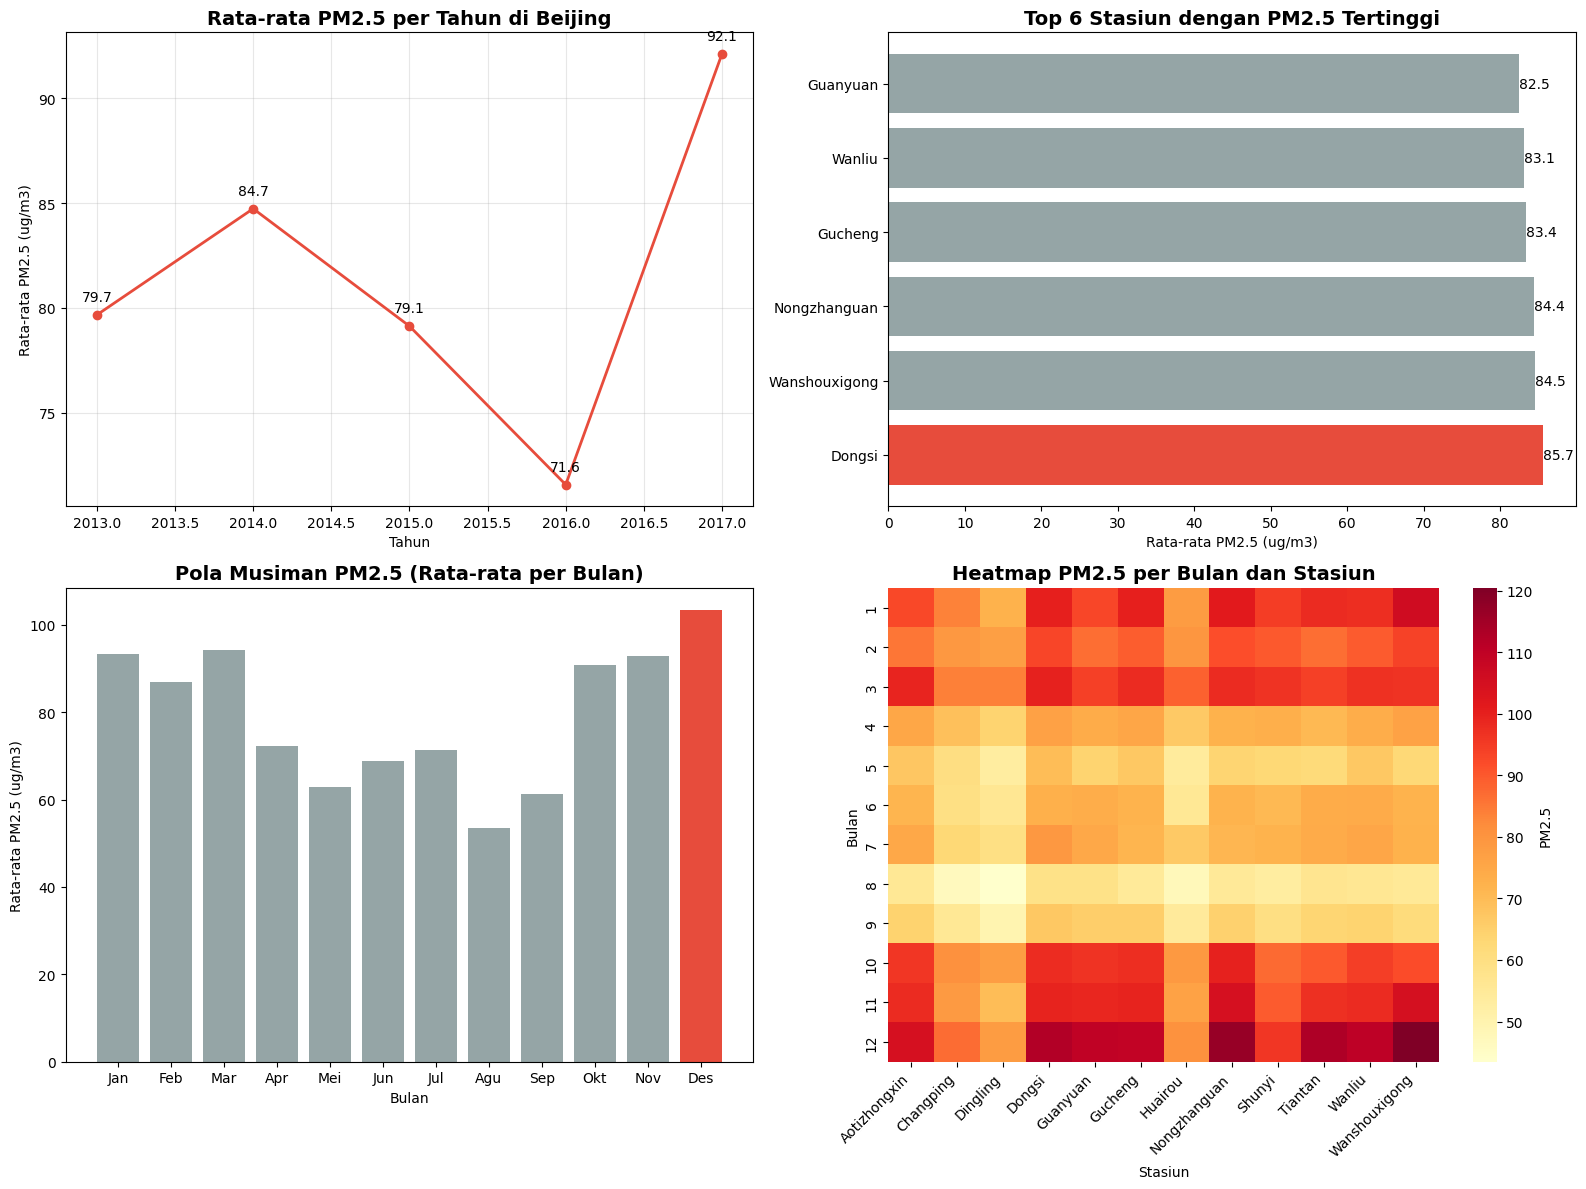

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

NEUTRAL = '#95a5a6'
HIGHLIGHT = '#e74c3c'

# Plot 1: Tren PM2.5 per tahun
axes[0, 0].plot(pm25_yearly_overall['year'], pm25_yearly_overall['avg_pm25'],
                marker='o', linewidth=2, color=HIGHLIGHT)
axes[0, 0].set_title('Rata-rata PM2.5 per Tahun di Beijing', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Tahun')
axes[0, 0].set_ylabel('Rata-rata PM2.5 (ug/m3)')
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(pm25_yearly_overall['avg_pm25']):
    axes[0, 0].annotate(f'{v:.1f}', (pm25_yearly_overall['year'].iloc[i], v),
                       textcoords='offset points', xytext=(0, 10), ha='center')

# Plot 2: PM2.5 per stasiun (Top 6) - satu warna netral, stasiun tertinggi disorot
top_stations = pm25_station.head(6)
colors = [HIGHLIGHT if s == top_stations.index[0] else NEUTRAL for s in top_stations.index]
bars = axes[0, 1].barh(top_stations.index, top_stations.values, color=colors)
axes[0, 1].set_title('Top 6 Stasiun dengan PM2.5 Tertinggi', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Rata-rata PM2.5 (ug/m3)')
for bar in bars:
    width = bar.get_width()
    axes[0, 1].text(width, bar.get_y() + bar.get_height()/2,
                   f'{width:.1f}', ha='left', va='center')

# Plot 3: Pola musiman PM2.5 - satu warna netral, bulan terpolusi disorot
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
max_month = pm25_monthly.loc[pm25_monthly['avg_pm25'].idxmax(), 'month']
bar_colors = [HIGHLIGHT if m == max_month else NEUTRAL for m in pm25_monthly['month']]
axes[1, 0].bar(pm25_monthly['month'], pm25_monthly['avg_pm25'], color=bar_colors)
axes[1, 0].set_title('Pola Musiman PM2.5 (Rata-rata per Bulan)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Bulan')
axes[1, 0].set_ylabel('Rata-rata PM2.5 (ug/m3)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names)

# Plot 4: Heatmap PM2.5 per bulan per stasiun (skala warna sequential relevan untuk heatmap)
monthly_station = df.groupby(['month', 'station'])['PM2.5'].mean().unstack()
sns.heatmap(monthly_station, cmap='YlOrRd', annot=False, fmt='.0f',
            ax=axes[1, 1], cbar_kws={'label': 'PM2.5'})
axes[1, 1].set_title('Heatmap PM2.5 per Bulan dan Stasiun', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Stasiun')
axes[1, 1].set_ylabel('Bulan')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('pm25_trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
- Trend tahunan (2013-2016) tidak monoton: PM2.5 memuncak di 2014 (84.7 ug/m3), lalu membaik ke 71.6 ug/m3 di 2016 - artinya ada perbaikan kualitas udara dalam periode tersebut meski masih jauh di atas ambang batas WHO (15 ug/m3 rata-rata tahunan).
- Dari 12 stasiun, 9 stasiun punya rata-rata PM2.5 di atas 75 ug/m3, dan seluruhnya berlokasi di area urban/pusat kota: Dongsi (85.7), Wanshouxigong (84.5), Nongzhanguan (84.4), Gucheng (83.4), Wanliu (83.1), Guanyuan (82.5), Aotizhongxin (82.1), Tiantan (81.7), dan Shunyi (78.9). Hanya Changping, Huairou, dan Dingling (stasiun pinggiran) yang berada di bawah ambang tersebut.
- Heatmap bulan x stasiun menunjukkan pola musiman berlaku merata di semua stasiun (bukan cuma sebagian) - musim dingin (Nov-Mar) konsisten merah tua di seluruh stasiun, mengindikasikan penyebabnya bersifat regional (pemanasan rumah tangga, cuaca dingin yang menahan polutan) dan bukan sekadar sumber lokal per stasiun.
- **Makna bisnis:** kebijakan pengendalian polusi paling efektif jika difokuskan pada 9 stasiun urban di atas dan diperketat khusus pada musim dingin, karena di situlah beban polusi paling besar dan paling konsisten terjadi setiap tahun.

### Pertanyaan 2: Perbandingan Weekday vs Weekend

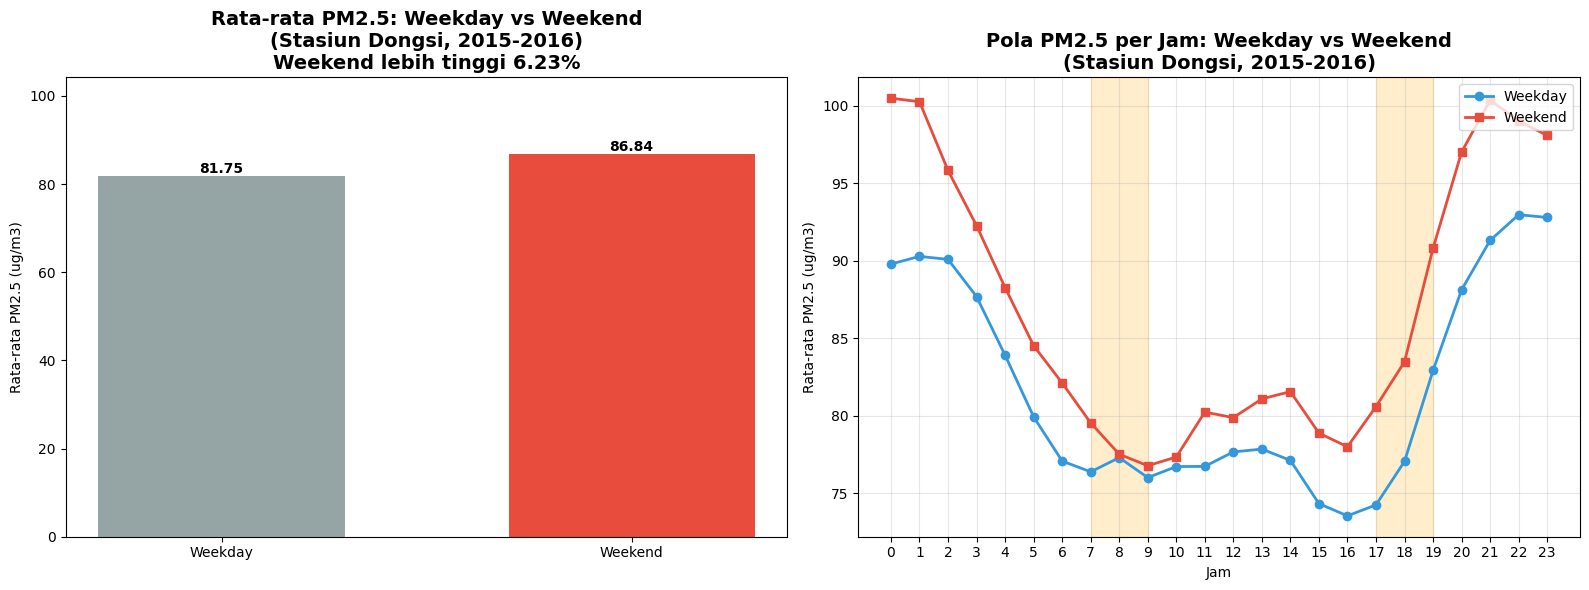

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart weekday vs weekend
categories = ['Weekday', 'Weekend']
values = [weekday_avg, weekend_avg]
colors = ['#95a5a6', '#e74c3c']  # weekend disorot karena nilainya lebih tinggi

bars = axes[0].bar(categories, values, color=colors, width=0.6)
axes[0].set_title(f'Rata-rata PM2.5: Weekday vs Weekend\n(Stasiun Dongsi, 2015-2016)\nWeekend {arah} {abs(pct_diff):.2f}%',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Rata-rata PM2.5 (ug/m3)')
axes[0].set_ylim(0, max(values) * 1.2)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Line chart per jam
axes[1].plot(hourly_comparison.index, hourly_comparison[False],
             marker='o', linewidth=2, color='#3498db', label='Weekday')
axes[1].plot(hourly_comparison.index, hourly_comparison[True],
             marker='s', linewidth=2, color='#e74c3c', label='Weekend')
axes[1].set_title('Pola PM2.5 per Jam: Weekday vs Weekend\n(Stasiun Dongsi, 2015-2016)',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Rata-rata PM2.5 (ug/m3)')
axes[1].set_xticks(range(0, 24))
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Highlight jam sibuk
axes[1].axvspan(7, 9, alpha=0.2, color='orange', label='Jam Sibuk Pagi')
axes[1].axvspan(17, 19, alpha=0.2, color='orange', label='Jam Sibuk Sore')

plt.tight_layout()
plt.savefig('weekday_vs_weekend.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
- Rata-rata PM2.5 di Dongsi pada weekend (86.84 ug/m3) lebih tinggi 6.23% dibanding weekday (81.75 ug/m3), bukan lebih rendah seperti dugaan awal - lalu lintas komuter kemungkinan bukan penyebab dominan di stasiun ini.
- Grafik per jam menunjukkan garis weekend (merah) berada di atas garis weekday (biru) hampir di seluruh jam, dengan gap terlebar pada malam-dini hari (jam 20-02, selisih 9-11 ug/m3) dan gap tersempit pada tengah hari (jam 9-13, selisih 1-3 ug/m3).
- **Makna bisnis:** pola ini menunjukkan sumber polusi akhir pekan di Dongsi lebih terkait aktivitas domestik malam hari (memasak, pemanasan, kumpul keluarga) dan kondisi atmosfer malam yang menahan polutan, ketimbang kemacetan jam kerja. Kebijakan pembatasan kendaraan pada jam sibuk saja tidak akan cukup untuk menurunkan polusi di stasiun ini - perlu intervensi tambahan yang menyasar emisi domestik dan malam hari.

## Analisis Lanjutan (Clustering Manual)

=== Clustering Stasiun Berdasarkan Kualitas Udara ===
          station   avg_pm25     category
3          Dongsi  85.655404  Tidak Sehat
11  Wanshouxigong  84.527421  Tidak Sehat
7    Nongzhanguan  84.375713  Tidak Sehat
5         Gucheng  83.412651  Tidak Sehat
10         Wanliu  83.109169  Tidak Sehat
4        Guanyuan  82.512914  Tidak Sehat
0    Aotizhongxin  82.120075  Tidak Sehat
9         Tiantan  81.717653  Tidak Sehat
8          Shunyi  78.853887  Tidak Sehat
1       Changping  70.545694  Tidak Sehat
6         Huairou  69.011408  Tidak Sehat
2        Dingling  65.434317  Tidak Sehat


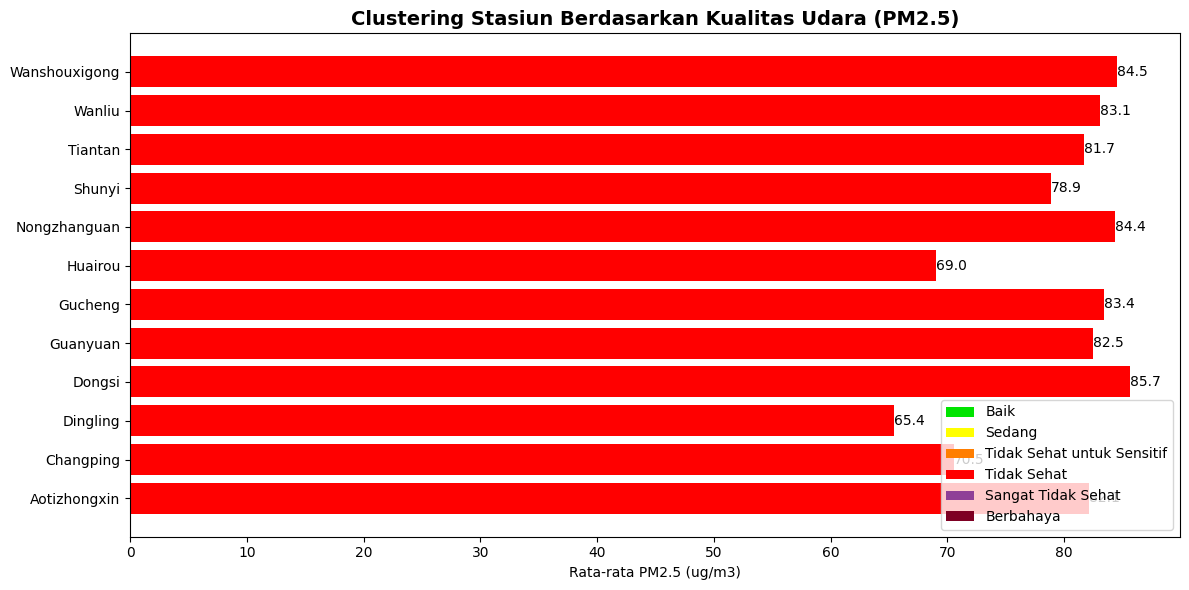

In [15]:
# Clustering Stasiun berdasarkan tingkat polusi PM2.5
# Tujuan: Mengelompokkan stasiun ke dalam kategori kualitas udara

station_pm25 = df.groupby('station')['PM2.5'].mean().reset_index()
station_pm25.columns = ['station', 'avg_pm25']

# Manual Grouping berdasarkan WHO Air Quality Guidelines
# PM2.5: Baik (0-12), Sedang (12.1-35.4), Tidak Sehat untuk Sensitif (35.5-55.4),
#        Tidak Sehat (55.5-150.4), Sangat Tidak Sehat (150.5-250.4), Berbahaya (>250.4)

def categorize_pm25(value):
    if value <= 12:
        return 'Baik'
    elif value <= 35.4:
        return 'Sedang'
    elif value <= 55.4:
        return 'Tidak Sehat untuk Sensitif'
    elif value <= 150.4:
        return 'Tidak Sehat'
    elif value <= 250.4:
        return 'Sangat Tidak Sehat'
    else:
        return 'Berbahaya'

station_pm25['category'] = station_pm25['avg_pm25'].apply(categorize_pm25)

print('=== Clustering Stasiun Berdasarkan Kualitas Udara ===')
print(station_pm25.sort_values('avg_pm25', ascending=False))

# Visualisasi clustering
fig, ax = plt.subplots(figsize=(12, 6))

colors_category = {
    'Baik': '#00e400',
    'Sedang': '#ffff00',
    'Tidak Sehat untuk Sensitif': '#ff7e00',
    'Tidak Sehat': '#ff0000',
    'Sangat Tidak Sehat': '#8f3f97',
    'Berbahaya': '#7e0023'
}

colors = [colors_category[cat] for cat in station_pm25['category']]
bars = ax.barh(station_pm25['station'], station_pm25['avg_pm25'], color=colors)
ax.set_xlabel('Rata-rata PM2.5 (ug/m3)')
ax.set_title('Clustering Stasiun Berdasarkan Kualitas Udara (PM2.5)', 
             fontsize=14, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_category[cat], label=cat) 
                   for cat in colors_category.keys()]
ax.legend(handles=legend_elements, loc='lower right')

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}', ha='left', va='center')

plt.tight_layout()
plt.savefig('clustering_stations.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
- Seluruh 12 stasiun jatuh pada kategori WHO **"Tidak Sehat"** (55.5-150.4 ug/m3) untuk rata-rata PM2.5-nya - tidak ada satu pun stasiun yang mencapai kategori "Baik" atau "Sedang", apalagi ambang tahunan WHO (15 ug/m3).
- Rentang antar stasiun cukup lebar (65.4-85.7 ug/m3, selisih ~20 ug/m3). Stasiun urban Dongsi (85.7), Wanshouxigong (84.5), dan Nongzhanguan (84.4) memiliki PM2.5 tertinggi, sedangkan stasiun pinggiran Dingling (65.4), Huairou (69.0), dan Changping (70.5) yang terendah.
- Pola ini konsisten dengan analisis Pertanyaan 1: stasiun di pusat kota secara sistematis lebih terpolusi dibanding pinggiran, kemungkinan karena kepadatan kendaraan, industri, dan bangunan yang menghambat dispersi udara.
- **Makna bisnis:** karena semua stasiun berstatus "Tidak Sehat", kebijakan mitigasi polusi perlu diterapkan di seluruh kota (bukan hanya di titik tertentu), dengan prioritas intervensi lebih besar di 3-4 stasiun urban dengan nilai tertinggi.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Rata-rata PM2.5 di Beijing pada 2013-2016 tidak naik terus-menerus - memuncak di 2014 (84.7 ug/m3) lalu membaik menjadi 71.6 ug/m3 di 2016 - namun pola musiman tetap konsisten setiap tahun, dengan puncak polusi di musim dingin (Nov-Feb) yang bisa melampaui 100 ug/m3. Dari 12 stasiun, 9 stasiun memiliki rata-rata PM2.5 di atas 75 ug/m3: Dongsi (85.7), Wanshouxigong (84.5), Nongzhanguan (84.4), Gucheng (83.4), Wanliu (83.1), Guanyuan (82.5), Aotizhongxin (82.1), Tiantan (81.7), dan Shunyi (78.9) - seluruhnya berada di area pusat kota Beijing.
- **Conclusion pertanyaan 2:** Di stasiun Dongsi tahun 2015-2016, rata-rata PM2.5 pada weekend (86.84 ug/m3) justru 6.23% lebih tinggi dibanding weekday (81.75 ug/m3), dengan gap terlebar pada malam-dini hari. Temuan ini berkebalikan dengan dugaan awal bahwa lalu lintas komuter adalah penyebab utama, dan mengarahkan pada dugaan baru: aktivitas domestik/rekreasi malam akhir pekan serta kondisi atmosfer yang menahan polutan turut berkontribusi besar terhadap polusi di stasiun ini.
- **Conclusion Analisis Lanjutan (Clustering AQI):** Berdasarkan pengelompokan manual mengikuti standar WHO Air Quality Guidelines, seluruh 12 stasiun tergolong kategori "Tidak Sehat" (55.5-150.4 ug/m3) untuk rata-rata PM2.5-nya, dengan rentang 65.4 ug/m3 (Dingling, terendah) hingga 85.7 ug/m3 (Dongsi, tertinggi). Tidak ada stasiun yang mencapai kategori "Baik" atau "Sedang", menunjukkan bahwa masalah kualitas udara di Beijing bersifat menyeluruh (kota-wide), bukan hanya terlokalisasi pada titik-titik tertentu, meski stasiun urban tetap secara sistematis lebih buruk daripada stasiun pinggiran.

**Rekomendasi Action Item:**
- Implementasi kebijakan pembatasan kendaraan pada jam sibuk (7-9 pagi dan 17-19 sore) untuk mengurangi kontribusi lalu lintas terhadap polusi di area pusat kota.
- Investigasi lebih lanjut terhadap sumber emisi domestik/malam hari di akhir pekan (misalnya pemanasan rumah tangga, aktivitas memasak, dan kumpul keluarga), karena data menunjukkan PM2.5 weekend justru lebih tinggi dari weekday - bukan sebaliknya seperti asumsi umum.
- Peningkatan penggunaan transportasi umum dan kendaraan listrik, terutama pada musim dingin (Nov-Feb) ketika polusi konsisten mencapai puncaknya setiap tahun.
- Penambahan area hijau dan penghijauan di sekitar stasiun urban dengan PM2.5 tertinggi (Dongsi, Wanshouxigong, Nongzhanguan, Gucheng).
- Pemberian peringatan kualitas udara kepada warga pada hari-hari dengan polusi tinggi, terutama bagi kelompok sensitif (anak-anak, lansia, penderita penyakit pernapasan), berlaku di seluruh kota karena semua stasiun tergolong "Tidak Sehat".
- Monitoring dan evaluasi berkala terhadap efektivitas kebijakan pengendalian polusi, termasuk memantau apakah tren perbaikan 2014-2016 berlanjut.